# Arcos Notáveis

**Módulo:** 05 – Trigonometria (5º notebook do módulo)

**Pré-requisitos:** [`04_geometria_plana/`](../04_geometria_plana/) (triângulo equilátero, triângulo retângulo isósceles, Teorema de Pitágoras), [`0503a_relacoes_fundamentais.ipynb`](0503a_relacoes_fundamentais.ipynb) (relação fundamental, usada para conferir os valores obtidos) e [`0504a_reducao_ao_1o_quadrante.ipynb`](0504a_reducao_ao_1o_quadrante.ipynb) (necessário para estender os valores notáveis a outros quadrantes)

**Objetivos de aprendizagem:**
- Deduzir geometricamente os valores exatos de seno, cosseno e tangente de 30°, 45° e 60°, sem depender de decorar uma tabela.
- Construir a tabela completa dos arcos notáveis (0°, 30°, 45°, 60°, 90°) e estendê-la a qualquer quadrante usando as reduções já aprendidas.
- Aplicar os arcos notáveis na resolução de um problema real, como o alcance de um lançamento oblíquo.
- Reconhecer arcos combinados (como 15°, 75°, 105°) como uma questão em aberto, que motiva o próximo notebook.

**Tempo estimado:** 65 a 85 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/05_trigonometria/0505a_arcos_notaveis.ipynb)

## A tabela que você não precisa decorar

Você provavelmente já viu uma tabela com os valores de seno, cosseno e tangente de 30°, 45° e 60° — e talvez tenha decorado sem entender de onde ela vem. E se, em vez de decorar, você pudesse desenhar dois triângulos bem simples e deduzir cada um desses valores sozinho, toda vez que esquecer?

Este notebook não apresenta nenhuma fórmula pronta: cada valor exato é deduzido geometricamente, a partir de dois triângulos que você já conhece.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    '''Aplica o estilo Nord padrão a um eixo do matplotlib.'''
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)

## 1. Por que Alguns Ângulos São "Notáveis"

Alguns ângulos aparecem com tanta frequência em geometria, física e engenharia — 30°, 45° e 60° — que vale a pena conhecer seus valores exatos de seno, cosseno e tangente. Mais do que decorá-los, o objetivo deste notebook é saber deduzi-los: a qualquer momento, a partir de dois triângulos simples.

Combinando esse conhecimento com a redução ao 1º quadrante estudada em `0504a_reducao_ao_1o_quadrante`, será possível calcular valores exatos de seno, cosseno e tangente em qualquer quadrante — não só entre 0° e 90°.

In [2]:
valor_aproximado = math.sin(math.radians(30))
valor_exato = sp.Rational(1, 2)

print(f"math.sin(radians(30)) = {valor_aproximado!r}")
print(f"valor exato sen(30°)  = {valor_exato} = {float(valor_exato)}")
print(f"diferença: {abs(valor_aproximado - float(valor_exato)):.2e}")

math.sin(radians(30)) = 0.49999999999999994
valor exato sen(30°)  = 1/2 = 0.5
diferença: 5.55e-17


🕵️ **Curiosidade histórica:** esses ângulos são "notáveis" em parte porque estão ligados a construções clássicas com régua e compasso: o triângulo equilátero e o quadrado são figuras fáceis de construir, e grande parte da geometria grega antiga se apoiava nelas.

📖 **Leitura complementar:** [Construções com régua e compasso — Wikipédia](https://pt.wikipedia.org/wiki/Constru%C3%A7%C3%B5es_com_r%C3%A9gua_e_compasso)

**Pergunta de checagem:** por que pode ser útil saber que sen(30°) = 1/2 exatamente, em vez de apenas o valor aproximado 0,4999999...?

## 2. Dedução Geométrica de 30° e 60°: o Triângulo Equilátero

Considere um triângulo equilátero de lado 2. Ao traçar a altura relativa a um dos lados, ele fica dividido em dois triângulos retângulos congruentes, cada um com ângulos de 30°, 60° e 90°.

A altura h desse triângulo satisfaz, pelo Teorema de Pitágoras: h² + 1² = 2², logo h = √3.

Esse triângulo retângulo tem catetos 1 e √3, e hipotenusa 2. A partir das razões entre esses lados:

**sen(30°) = 1/2**       **cos(30°) = √3/2**       **tg(30°) = √3/3**

**sen(60°) = √3/2**      **cos(60°) = 1/2**       **tg(60°) = √3**

In [3]:
lado_triangulo = 2
cateto_oposto_30 = 1  # metade do lado, base de cada triângulo retângulo formado pela altura
hipotenusa = lado_triangulo
altura = math.sqrt(hipotenusa ** 2 - cateto_oposto_30 ** 2)  # Teorema de Pitágoras

print(f"lado do triângulo equilátero: {lado_triangulo}")
print(f"altura (cateto adjacente):    {altura:.6f}  (= √3 = {math.sqrt(3):.6f})")

sen_30 = cateto_oposto_30 / hipotenusa
cos_30 = altura / hipotenusa
tg_30 = cateto_oposto_30 / altura

sen_60 = altura / hipotenusa
cos_60 = cateto_oposto_30 / hipotenusa
tg_60 = altura / cateto_oposto_30

assert abs(sen_30 - math.sin(math.radians(30))) < 1e-9
assert abs(cos_30 - math.cos(math.radians(30))) < 1e-9
assert abs(sen_60 - math.sin(math.radians(60))) < 1e-9
assert abs(cos_60 - math.cos(math.radians(60))) < 1e-9

tabela_30_60 = pd.DataFrame({
    "ângulo": ["30°", "60°"],
    "sen": [round(sen_30, 4), round(sen_60, 4)],
    "cos": [round(cos_30, 4), round(cos_60, 4)],
    "tg": [round(tg_30, 4), round(tg_60, 4)],
})
tabela_30_60

lado do triângulo equilátero: 2
altura (cateto adjacente):    1.732051  (= √3 = 1.732051)


,ângulo,sen,cos,tg
0,30°,0.500,0.866,0.5774
1,60°,0.866,0.500,1.7321


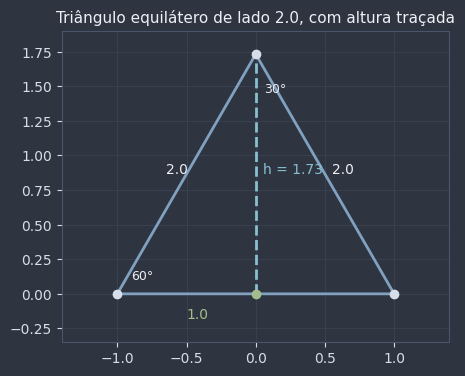

In [4]:
def plotar_triangulo_equilatero(lado: float) -> None:
    '''Desenha um triângulo equilátero de lado `lado` com a altura traçada, destacando os dois triângulos retângulos de 30°-60°-90°.'''
    metade = lado / 2
    altura = math.sqrt(lado ** 2 - metade ** 2)

    base_esq = (-metade, 0)
    base_dir = (metade, 0)
    topo = (0, altura)

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    xs = [base_esq[0], base_dir[0], topo[0], base_esq[0]]
    ys = [base_esq[1], base_dir[1], topo[1], base_esq[1]]
    ax.plot(xs, ys, color=COR_SECUNDARIA, linewidth=2)
    ax.plot([0, 0], [0, altura], color=COR_PONTO, linewidth=2, linestyle="--")

    ax.plot(*base_esq, "o", color=NORD_TEXTO_SEC)
    ax.plot(*base_dir, "o", color=NORD_TEXTO_SEC)
    ax.plot(0, altura, "o", color=NORD_TEXTO_SEC)
    ax.plot(0, 0, "o", color=COR_DESTAQUE)

    ax.annotate(f"{lado:.1f}", xy=(-metade / 2 - 0.15, altura / 2), color=NORD_TEXTO, fontsize=10)
    ax.annotate(f"{lado:.1f}", xy=(metade / 2 + 0.05, altura / 2), color=NORD_TEXTO, fontsize=10)
    ax.annotate(f"{metade:.1f}", xy=(-metade / 2, -0.18), color=COR_DESTAQUE, fontsize=10)
    ax.annotate(f"h = {altura:.2f}", xy=(0.05, altura / 2), color=COR_PONTO, fontsize=10)
    ax.annotate("30°", xy=(0.06, altura - 0.28), color=NORD_TEXTO, fontsize=9)
    ax.annotate("60°", xy=(-metade + 0.1, 0.1), color=NORD_TEXTO, fontsize=9)

    ax.set_xlim(-lado * 0.7, lado * 0.7)
    ax.set_ylim(-0.35, lado * 0.95)
    ax.set_aspect("equal")
    ax.set_title(f"Triângulo equilátero de lado {lado:.1f}, com altura traçada", color=NORD_TEXTO, fontsize=11)
    plt.show()


plotar_triangulo_equilatero(2)

🕹️ **Widget interativo:** varie o comprimento do lado do triângulo equilátero e observe que o desenho muda de tamanho, mas os ângulos — e portanto os valores de seno, cosseno e tangente — permanecem sempre os mesmos.

In [5]:
def widget_triangulo_equilatero(lado: float) -> None:
    plotar_triangulo_equilatero(lado)

    metade = lado / 2
    altura = math.sqrt(lado ** 2 - metade ** 2)
    sen_30_v = metade / lado
    cos_30_v = altura / lado
    tg_30_v = metade / altura

    tabela = pd.DataFrame({
        "razão": [
            "sen(30°) = cateto oposto / hipotenusa",
            "cos(30°) = cateto adjacente / hipotenusa",
            "tg(30°) = cateto oposto / cateto adjacente",
        ],
        "valor": [round(sen_30_v, 4), round(cos_30_v, 4), round(tg_30_v, 4)],
    })
    display(tabela)


widgets.interact(
    widget_triangulo_equilatero,
    lado=widgets.FloatSlider(min=1, max=6, step=0.5, value=2, description="lado"),
)

interactive(children=(FloatSlider(value=2.0, description='lado', max=6.0, min=1.0, step=0.5), Output()), _dom_…

<function __main__.widget_triangulo_equilatero(lado: float) -> None>

📌 **Valores exatos de 30° e 60°:**

| ângulo | sen | cos | tg |
|---|---|---|---|
| 30° | 1/2 | √3/2 | √3/3 |
| 60° | √3/2 | 1/2 | √3 |

**Pergunta de checagem:** por que dividir o triângulo equilátero ao meio (traçando a altura) gera exatamente um ângulo de 30° em cada metade?

## 3. Dedução Geométrica de 45°: o Quadrado

Considere um quadrado de lado 1. Sua diagonal o divide em dois triângulos retângulos isósceles, com ângulos de 45°, 45° e 90°, e catetos iguais a 1.

Pelo Teorema de Pitágoras, a diagonal (hipotenusa desses triângulos) mede: d² = 1² + 1² = 2, logo d = √2.

A partir das razões entre os lados desse triângulo:

**sen(45°) = √2/2**       **cos(45°) = √2/2**       **tg(45°) = 1**

In [6]:
cateto_exemplo = 1
diagonal_exemplo = cateto_exemplo * math.sqrt(2)  # Teorema de Pitágoras: d² = 1² + 1²

print(f"cateto do triângulo isósceles: {cateto_exemplo}")
print(f"diagonal (hipotenusa):         {diagonal_exemplo:.6f}  (= √2 = {math.sqrt(2):.6f})")

sen_45 = cateto_exemplo / diagonal_exemplo
cos_45 = cateto_exemplo / diagonal_exemplo
tg_45 = cateto_exemplo / cateto_exemplo

assert abs(sen_45 - math.sin(math.radians(45))) < 1e-9
assert abs(cos_45 - math.cos(math.radians(45))) < 1e-9
assert abs(tg_45 - math.tan(math.radians(45))) < 1e-9

tabela_45 = pd.DataFrame({
    "ângulo": ["45°"],
    "sen": [round(sen_45, 4)],
    "cos": [round(cos_45, 4)],
    "tg": [round(tg_45, 4)],
})
tabela_45

cateto do triângulo isósceles: 1
diagonal (hipotenusa):         1.414214  (= √2 = 1.414214)


,ângulo,sen,cos,tg
0,45°,0.7071,0.7071,1.0


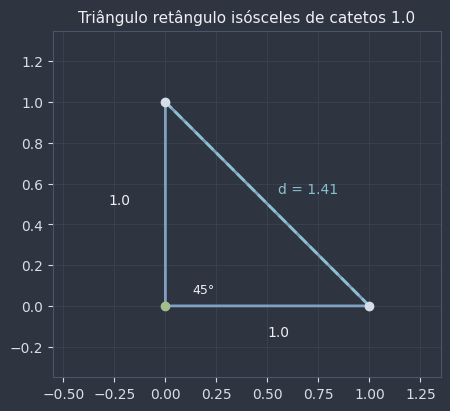

In [7]:
def plotar_triangulo_isosceles(cateto: float) -> None:
    '''Desenha um triângulo retângulo isósceles de catetos iguais a `cateto`, com a hipotenusa (diagonal do quadrado) destacada.'''
    diagonal = cateto * math.sqrt(2)

    origem = (0, 0)
    ponto_x = (cateto, 0)
    ponto_y = (0, cateto)

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    xs = [origem[0], ponto_x[0], ponto_y[0], origem[0]]
    ys = [origem[1], ponto_x[1], ponto_y[1], origem[1]]
    ax.plot(xs, ys, color=COR_SECUNDARIA, linewidth=2)
    ax.plot([ponto_x[0], ponto_y[0]], [ponto_x[1], ponto_y[1]], color=COR_PONTO, linewidth=2, linestyle="--")

    ax.plot(*origem, "o", color=COR_DESTAQUE)
    ax.plot(*ponto_x, "o", color=NORD_TEXTO_SEC)
    ax.plot(*ponto_y, "o", color=NORD_TEXTO_SEC)

    ax.annotate(f"{cateto:.1f}", xy=(cateto / 2, -0.15), color=NORD_TEXTO, fontsize=10)
    ax.annotate(f"{cateto:.1f}", xy=(-0.28, cateto / 2), color=NORD_TEXTO, fontsize=10)
    ax.annotate(f"d = {diagonal:.2f}", xy=(cateto / 2 + 0.05, cateto / 2 + 0.05), color=COR_PONTO, fontsize=10)
    ax.annotate("45°", xy=(0.13, 0.06), color=NORD_TEXTO, fontsize=9)

    ax.set_xlim(-0.55, cateto * 1.35)
    ax.set_ylim(-0.35, cateto * 1.35)
    ax.set_aspect("equal")
    ax.set_title(f"Triângulo retângulo isósceles de catetos {cateto:.1f}", color=NORD_TEXTO, fontsize=11)
    plt.show()


plotar_triangulo_isosceles(cateto_exemplo)

💡 **Dica:** como os dois catetos do triângulo são iguais, já era esperado que sen(45°) = cos(45°), mesmo antes de calcular qualquer coisa — a simetria do triângulo garante isso.

**Pergunta de checagem:** por que tg(45°) vale exatamente 1?

## 4. Tabela Consolidada e Extensão a Outros Quadrantes

Os casos de 0° e 90° não exigem nenhum triângulo: saem diretamente do ciclo trigonométrico, olhando para os pontos (1, 0) e (0, 1).

| ângulo | sen | cos | tg |
|---|---|---|---|
| 0° | 0 | 1 | 0 |
| 30° | 1/2 | √3/2 | √3/3 |
| 45° | √2/2 | √2/2 | 1 |
| 60° | √3/2 | 1/2 | √3 |
| 90° | 1 | 0 | não existe |

Combinando essa tabela com a redução ao 1º quadrante (`0504a_reducao_ao_1o_quadrante`), é possível calcular exatamente seno, cosseno e tangente de qualquer múltiplo de 30° ou 45°, em qualquer quadrante — por exemplo, 150°, 225° ou 300°.

In [8]:
BASES_NOTAVEIS = {
    30: {"sen": sp.Rational(1, 2), "cos": sp.sqrt(3) / 2, "tg": sp.sqrt(3) / 3},
    45: {"sen": sp.sqrt(2) / 2, "cos": sp.sqrt(2) / 2, "tg": sp.Integer(1)},
    60: {"sen": sp.sqrt(3) / 2, "cos": sp.Rational(1, 2), "tg": sp.sqrt(3)},
}


def formatar(valor) -> str:
    '''Formata um valor exato para exibição, tratando tangentes indefinidas.'''
    return "não existe" if valor is None else str(valor)


tabela_notaveis_completa = {
    0: {"sen": sp.Integer(0), "cos": sp.Integer(1), "tg": sp.Integer(0)},
    **BASES_NOTAVEIS,
    90: {"sen": sp.Integer(1), "cos": sp.Integer(0), "tg": None},
}

tabela_notaveis_df = pd.DataFrame({
    "ângulo": [f"{a}°" for a in tabela_notaveis_completa],
    "sen": [formatar(v["sen"]) for v in tabela_notaveis_completa.values()],
    "cos": [formatar(v["cos"]) for v in tabela_notaveis_completa.values()],
    "tg": [formatar(v["tg"]) for v in tabela_notaveis_completa.values()],
})
tabela_notaveis_df

,ângulo,sen,cos,tg
0,0°,0,1,0
1,30°,1/2,sqrt(3)/2,sqrt(3)/3
2,45°,sqrt(2)/2,sqrt(2)/2,1
3,60°,sqrt(3)/2,1/2,sqrt(3)
4,90°,1,0,não existe


In [9]:
def quadrante(angulo_graus: int) -> str:
    '''Determina o quadrante de um ângulo entre 0° e 360°, tratando os múltiplos de 90° separadamente (função reaproveitada de 0504a_reducao_ao_1o_quadrante).'''
    if angulo_graus in (0, 90, 180, 270):
        return "sobre um eixo"
    if angulo_graus < 90:
        return "1º quadrante"
    if angulo_graus < 180:
        return "2º quadrante"
    if angulo_graus < 270:
        return "3º quadrante"
    return "4º quadrante"


def valor_exato_notavel(angulo_graus: int) -> dict[str, sp.Expr | None]:
    '''Calcula sen, cos e tg exatos de um ângulo múltiplo de 30° ou 45°, em
    qualquer quadrante, combinando os arcos notáveis do 1º quadrante com a
    redução ao 1º quadrante.'''
    angulo_no_ciclo = angulo_graus % 360

    if angulo_no_ciclo == 0:
        return {"sen": sp.Integer(0), "cos": sp.Integer(1), "tg": sp.Integer(0)}
    if angulo_no_ciclo == 90:
        return {"sen": sp.Integer(1), "cos": sp.Integer(0), "tg": None}
    if angulo_no_ciclo == 180:
        return {"sen": sp.Integer(0), "cos": sp.Integer(-1), "tg": sp.Integer(0)}
    if angulo_no_ciclo == 270:
        return {"sen": sp.Integer(-1), "cos": sp.Integer(0), "tg": None}

    q = quadrante(angulo_no_ciclo)
    if q == "1º quadrante":
        angulo_1q, sinal_sen, sinal_cos = angulo_no_ciclo, 1, 1
    elif q == "2º quadrante":
        angulo_1q, sinal_sen, sinal_cos = 180 - angulo_no_ciclo, 1, -1
    elif q == "3º quadrante":
        angulo_1q, sinal_sen, sinal_cos = angulo_no_ciclo - 180, -1, -1
    else:  # 4º quadrante
        angulo_1q, sinal_sen, sinal_cos = 360 - angulo_no_ciclo, -1, 1

    base = BASES_NOTAVEIS[angulo_1q]
    sen_x = sinal_sen * base["sen"]
    cos_x = sinal_cos * base["cos"]
    tg_x = sen_x / cos_x
    return {"sen": sen_x, "cos": cos_x, "tg": tg_x}


for angulo in [150, 225, 300, 120, 315]:
    resultado = valor_exato_notavel(angulo)
    assert abs(float(resultado["sen"]) - math.sin(math.radians(angulo))) < 1e-9, f"sen falhou para {angulo}°"
    assert abs(float(resultado["cos"]) - math.cos(math.radians(angulo))) < 1e-9, f"cos falhou para {angulo}°"
    print(f"{angulo:>3}°:   sen = {resultado['sen']} ≈ {float(resultado['sen']):.4f}   |   cos = {resultado['cos']} ≈ {float(resultado['cos']):.4f}")

print("\nvalor_exato_notavel bate com math.sin/math.cos para todos os ângulos testados.")

150°:   sen = 1/2 ≈ 0.5000   |   cos = -sqrt(3)/2 ≈ -0.8660
225°:   sen = -sqrt(2)/2 ≈ -0.7071   |   cos = -sqrt(2)/2 ≈ -0.7071
300°:   sen = -sqrt(3)/2 ≈ -0.8660   |   cos = 1/2 ≈ 0.5000
120°:   sen = sqrt(3)/2 ≈ 0.8660   |   cos = -1/2 ≈ -0.5000
315°:   sen = -sqrt(2)/2 ≈ -0.7071   |   cos = sqrt(2)/2 ≈ 0.7071

valor_exato_notavel bate com math.sin/math.cos para todos os ângulos testados.


📎 **Conexão:** as funções `quadrante` e a lógica de redução vêm de `0504a_reducao_ao_1o_quadrante` — aqui elas são combinadas com a tabela de arcos notáveis para produzir valores exatos (não aproximados) em qualquer quadrante.

⚠️ **Erro comum:** trocar os valores de seno e cosseno entre 30° e 60° — sen(30°) = cos(60°) = 1/2, e é fácil confundir um pelo outro na hora de decorar.

**Pergunta de checagem:** qual o valor exato de cos(225°)? (Dica: primeiro reduza ao 1º quadrante.)

## 5. Aplicação Prática: Lançamento Oblíquo com Ângulos Notáveis

O alcance horizontal de um lançamento oblíquo (sem resistência do ar), com velocidade inicial v₀ e ângulo de lançamento θ, é dado por:

**A = v₀²·sen(2θ) / g**

onde g é a aceleração da gravidade (≈ 9,8 m/s²). Usando ângulos notáveis para θ, é possível calcular esse alcance de forma exata, sem aproximações decimais.

In [10]:
def alcance_obliquo_exato(v0: int, g: sp.Rational, angulo_graus: int) -> sp.Expr:
    '''Calcula o alcance exato de um lançamento oblíquo, A = v0²·sen(2θ)/g, para θ múltiplo de 30° ou 45°.'''
    sen_2theta = valor_exato_notavel(2 * angulo_graus)["sen"]
    return sp.Integer(v0) ** 2 * sen_2theta / g


v0_lancamento = 20  # m/s
g_lancamento = sp.Rational(98, 10)  # 9,8 m/s², como fração exata para manter o cálculo simbólico

for angulo in [30, 45, 60]:
    alcance = alcance_obliquo_exato(v0_lancamento, g_lancamento, angulo)
    print(f"θ = {angulo:>2}°   A = {alcance} ≈ {float(alcance):.4f} m")

alcance_30 = alcance_obliquo_exato(v0_lancamento, g_lancamento, 30)
alcance_45 = alcance_obliquo_exato(v0_lancamento, g_lancamento, 45)
alcance_60 = alcance_obliquo_exato(v0_lancamento, g_lancamento, 60)

assert alcance_30 == alcance_60, "alcances de 30° e 60° deveriam ser exatamente iguais"
assert alcance_45 > alcance_30, "45° deveria dar o maior alcance"
print("\n30° e 60° dão exatamente o mesmo alcance; 45° dá o alcance máximo.")

θ = 30°   A = 1000*sqrt(3)/49 ≈ 35.3480 m
θ = 45°   A = 2000/49 ≈ 40.8163 m
θ = 60°   A = 1000*sqrt(3)/49 ≈ 35.3480 m

30° e 60° dão exatamente o mesmo alcance; 45° dá o alcance máximo.


In [11]:
def trajetoria_obliqua(v0: float, g: float, angulo_graus: float, n_pontos: int = 200):
    '''Calcula os pontos (x, y) da trajetória parabólica de um lançamento oblíquo, e o alcance.'''
    angulo_rad = math.radians(angulo_graus)
    alcance = (v0 ** 2) * math.sin(2 * angulo_rad) / g
    xs = np.linspace(0, max(alcance, 1e-6), n_pontos)
    ys = xs * math.tan(angulo_rad) - (g * xs ** 2) / (2 * v0 ** 2 * math.cos(angulo_rad) ** 2)
    return xs, ys, alcance


def widget_lancamento_obliquo(angulo_graus: float) -> None:
    v0_num, g_num = 20.0, 9.8
    xs, ys, alcance = trajetoria_obliqua(v0_num, g_num, angulo_graus)

    fig, ax = plt.subplots(figsize=(7, 4))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    ax.plot(xs, ys, color=COR_PONTO, linewidth=2)
    ax.fill_between(xs, ys, color=COR_PONTO, alpha=0.15)

    for angulo_notavel, cor in [(30, COR_DESTAQUE), (45, COR_AVISO), (60, COR_ALERTA)]:
        _, _, alcance_notavel = trajetoria_obliqua(v0_num, g_num, angulo_notavel)
        ax.axvline(
            alcance_notavel, color=cor, linestyle="--", linewidth=1, alpha=0.7,
            label=f"{angulo_notavel}° (A={alcance_notavel:.1f} m)",
        )

    ax.set_xlim(0, 45)
    ax.set_ylim(0, 25)
    ax.set_xlabel("distância horizontal (m)", color=NORD_TEXTO_SEC)
    ax.set_ylabel("altura (m)", color=NORD_TEXTO_SEC)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8, loc="upper right")
    ax.set_title(f"θ = {angulo_graus:.0f}°   |   alcance A = {alcance:.2f} m", color=NORD_TEXTO, fontsize=11)
    plt.show()


widgets.interact(
    widget_lancamento_obliquo,
    angulo_graus=widgets.IntSlider(min=0, max=90, step=1, value=45, description="θ (°)"),
)

interactive(children=(IntSlider(value=45, description='θ (°)', max=90), Output()), _dom_classes=('widget-inter…

<function __main__.widget_lancamento_obliquo(angulo_graus: float) -> None>

💡 **Dica:** sempre que dois ângulos de lançamento somam 90° (como 30° e 60°, ou 20° e 70°), o alcance é o mesmo — porque sen(2θ) = sen(180° − 2θ), e 180° − 2θ = 2(90° − θ). Vale a pena guardar essa simetria.

📖 **Leitura complementar:** [Movimento parabólico — Wikipédia](https://pt.wikipedia.org/wiki/Movimento_parab%C3%B3lico)

**Pergunta de checagem:** sem calcular, qual outro ângulo de lançamento dá o mesmo alcance que um lançamento a 20°?

## 6. Arcos Combinados: um Problema em Aberto

E se quisermos o valor exato de sen(15°)? Não é um dos cinco ângulos da tabela — mas 15° = 45° − 30°, uma combinação de dois ângulos notáveis.

Seria tentador simplesmente "subtrair" os valores: sen(45°) − sen(30°). Será que funciona?

In [12]:
sen_15_real = math.sin(math.radians(15))
tentativa_ingenua = math.sin(math.radians(45)) - math.sin(math.radians(30))

print(f"sen(15°) real:                  {sen_15_real:.6f}")
print(f"sen(45°) - sen(30°) (tentativa): {tentativa_ingenua:.6f}")
print(f"diferença: {abs(sen_15_real - tentativa_ingenua):.6f}")

assert abs(sen_15_real - tentativa_ingenua) > 1e-3, "a tentativa ingênua deveria falhar"
print("\nOs valores não coincidem: subtrair senos não é a fórmula certa.")

sen(15°) real:                  0.258819
sen(45°) - sen(30°) (tentativa): 0.207107
diferença: 0.051712

Os valores não coincidem: subtrair senos não é a fórmula certa.


📎 **Conexão:** 📌 Transformações deduz a fórmula correta para sen(a − b) — e resolve exatamente essa pergunta.

**Pergunta de checagem (em aberto):** já que sen(45°) − sen(30°) não é sen(15°), que outras combinações de sen(30°), cos(30°), sen(45°) e cos(45°) você tentaria para chegar em sen(15°)?

## Resumo — cheat sheet

| ângulo | sen | cos | tg |
|---|---|---|---|
| 0° | 0 | 1 | 0 |
| 30° | 1/2 | √3/2 | √3/3 |
| 45° | √2/2 | √2/2 | 1 |
| 60° | √3/2 | 1/2 | √3 |
| 90° | 1 | 0 | não existe |

**Como deduzir rapidamente:**
- 30° e 60°: triângulo equilátero de lado 2, com a altura traçada (h = √3) — dois triângulos retângulos de 30°-60°-90°.
- 45°: quadrado de lado 1, com a diagonal traçada (d = √2) — triângulo retângulo isósceles de 45°-45°-90°.

**Lançamento oblíquo:** A = v₀²·sen(2θ)/g
- θ = 45° dá o alcance máximo.
- Ângulos que somam 90° (como 30° e 60°) dão o mesmo alcance.

⚠️ Arcos combinados (15°, 75°, 105°...) exigem fórmulas ainda não vistas — assunto do próximo notebook, 📌 Transformações.

## Exercícios

**Básico**
1. Calcular, sem calculadora, sen, cos e tg de 30°, 45°, 60° e 90°.
2. Deduzir novamente, do zero, os valores de 30° e 45° a partir dos triângulos vistos nos Blocos 2 e 3.

**Intermediário**
3. Calcular valores exatos de ângulos em outros quadrantes (120°, 135°, 210°, 315°), combinando a tabela com a redução ao 1º quadrante.
4. Dado um alcance desejado, descobrir qual ângulo notável de lançamento o produziria.

**Desafio**
5. Comparar numericamente por que um lançamento a 30° e outro a 60° alcançam a mesma distância, usando a simetria do seno.
6. Investigar numericamente (por tentativa) alguma combinação de sen(30°), cos(30°), sen(45°) e cos(45°) que se aproxime do valor real de sen(15°) — problema aberto, sem resposta fechada.

### Básico

In [ ]:
# Exercício Básico 1: calcule sen, cos e tg de 30°, 45°, 60° e 90° usando os
# valores exatos deduzidos nos Blocos 2, 3 e 4 (não use math.sin/cos/tan
# diretamente). Guarde o resultado como um dicionário no formato
# {angulo: {"sen": ..., "cos": ..., "tg": ...}}, com os valores como float
# arredondados a 4 casas decimais (tg de 90° deve ficar None, já que não
# existe).
tabela_exercicio1 = ...


In [ ]:
# Verificação
esperado_exercicio1 = {
    30: {"sen": 0.5, "cos": round(math.sqrt(3) / 2, 4), "tg": round(math.sqrt(3) / 3, 4)},
    45: {"sen": round(math.sqrt(2) / 2, 4), "cos": round(math.sqrt(2) / 2, 4), "tg": 1.0},
    60: {"sen": round(math.sqrt(3) / 2, 4), "cos": 0.5, "tg": round(math.sqrt(3), 4)},
    90: {"sen": 1.0, "cos": 0.0, "tg": None},
}
for angulo, valores in esperado_exercicio1.items():
    for funcao, esperado in valores.items():
        obtido = tabela_exercicio1[angulo][funcao]
        if esperado is None:
            assert obtido is None, (
                "Tente de novo, revise: tg(90°) não existe (seção 4 - Tabela "
                "Consolidada e Extensão a Outros Quadrantes)."
            )
        else:
            assert abs(obtido - esperado) < 1e-3, (
                f"Tente de novo, revise: confira {funcao}({angulo}°) usando os "
                "triângulos dos Blocos 2 e 3 (seção 4 - Tabela Consolidada e "
                "Extensão a Outros Quadrantes)."
            )
print("Certo!")

In [ ]:
# Exercício Básico 2: sem consultar a tabela pronta, deduza de novo os
# valores de sen(30°) e sen(45°) a partir dos triângulos dos Blocos 2 e 3.
# Para 30°, use um triângulo equilátero de lado 2 (cateto oposto = 1,
# hipotenusa = 2). Para 45°, use um triângulo retângulo isósceles de catetos
# iguais a 1 (hipotenusa = √2). Guarde o resultado como uma tupla
# (sen_30_deduzido, sen_45_deduzido), ambos arredondados a 4 casas decimais.
sen_30_deduzido = ...
sen_45_deduzido = ...


In [ ]:
# Verificação
esperado_sen_30 = round(1 / 2, 4)
esperado_sen_45 = round(1 / math.sqrt(2), 4)
assert (sen_30_deduzido, sen_45_deduzido) == (esperado_sen_30, esperado_sen_45), (
    "Tente de novo, revise: no triângulo equilátero, sen(30°) = cateto oposto "
    "(1) / hipotenusa (2); no triângulo isósceles, sen(45°) = cateto (1) / "
    "hipotenusa (√2) (seção 2 e 3 - Dedução Geométrica de 30°/60° e 45°)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: calcule os valores exatos de sen(120°),
# cos(135°), tg(210°) e sen(315°), combinando a tabela de arcos notáveis com
# a redução ao 1º quadrante (função valor_exato_notavel). Guarde o resultado
# como uma lista de floats [sen(120°), cos(135°), tg(210°), sen(315°)],
# arredondados a 4 casas decimais.
resultados_exercicio3 = ...


In [ ]:
# Verificação
esperado_exercicio3 = [
    round(math.sin(math.radians(120)), 4),
    round(math.cos(math.radians(135)), 4),
    round(math.tan(math.radians(210)), 4),
    round(math.sin(math.radians(315)), 4),
]
assert resultados_exercicio3 == esperado_exercicio3, (
    "Tente de novo, revise: use valor_exato_notavel para cada ângulo e "
    "compare com float() do resultado (seção 4 - Tabela Consolidada e "
    "Extensão a Outros Quadrantes)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: um projétil precisa de um alcance de
# aproximadamente 40.8 m, com v0 = 20 m/s e g = 9.8 m/s². Descubra, entre os
# ângulos notáveis 30°, 45° e 60°, qual deles produz esse alcance. Guarde a
# resposta em angulo_alcance_desejado (int).
angulo_alcance_desejado = ...


In [ ]:
# Verificação
alcance_desejado = 40.8
candidatos = {angulo: (20 ** 2) * math.sin(math.radians(2 * angulo)) / 9.8 for angulo in (30, 45, 60)}
esperado_angulo = min(candidatos, key=lambda a: abs(candidatos[a] - alcance_desejado))
assert angulo_alcance_desejado == esperado_angulo, (
    "Tente de novo, revise: calcule A = v0²·sen(2θ)/g para θ = 30°, 45° e "
    "60°, e compare com o alcance desejado (seção 5 - Aplicação Prática: "
    "Lançamento Oblíquo com Ângulos Notáveis)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: sem usar a fórmula do alcance A = v0²·sen(2θ)/g,
# explique numericamente por que um lançamento a 30° e outro a 60° alcançam
# a mesma distância. Dica: compare sen(2*30°) e sen(2*60°) usando a simetria
# sen(x) = sen(180° - x) (vista em 0504a_reducao_ao_1o_quadrante). Guarde o
# resultado como uma tupla (sen_60, sen_120, angulos_sao_simetricos), com os
# dois primeiros arredondados a 4 casas decimais, e angulos_sao_simetricos
# um bool que confirme que 180° - 60° == 120°.
sen_60 = ...
sen_120 = ...
angulos_sao_simetricos = ...


In [ ]:
# Verificação
esperado_sen_60 = round(math.sin(math.radians(60)), 4)
esperado_sen_120 = round(math.sin(math.radians(120)), 4)
assert (sen_60, sen_120, angulos_sao_simetricos) == (esperado_sen_60, esperado_sen_120, True), (
    "Tente de novo, revise: sen(2·30°) = sen(60°) e sen(2·60°) = sen(120°); "
    "120° = 180° - 60°, então sen(120°) = sen(60°) pela simetria do 2º "
    "quadrante (seção 5 - Aplicação Prática: Lançamento Oblíquo com Ângulos "
    "Notáveis)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6 (problema em aberto): tente encontrar uma combinação
# de sen(30°), cos(30°), sen(45°) e cos(45°) que se aproxime do valor real
# de sen(15°) ≈ 0.2588. Não existe uma resposta "errada" aqui -- guarde sua
# tentativa (um float) em tentativa_sen_15; a célula seguinte mostra o quão
# perto você chegou, sem exigir acerto exato.
tentativa_sen_15 = ...


In [ ]:
# Verificação
sen_15_real = round(math.sin(math.radians(15)), 4)
diferenca = abs(tentativa_sen_15 - sen_15_real)
print(f"sen(15°) real:      {sen_15_real}")
print(f"sua tentativa:      {tentativa_sen_15}")
print(f"diferença:          {diferenca:.4f}")
print("\nNão existe resposta certa ainda -- essa pergunta será respondida em 📌 Transformações.")

## Glossário do bloco

| Termo | Definição |
|---|---|
| Arco notável | ângulo cujo seno, cosseno e tangente têm valor exato conhecido (aqui: 0°, 30°, 45°, 60°, 90°) |
| Triângulo retângulo 30-60-90 | metade de um triângulo equilátero, obtida traçando sua altura |
| Triângulo retângulo isósceles (45-45-90) | metade de um quadrado, obtida traçando sua diagonal |
| Alcance (lançamento oblíquo) | distância horizontal percorrida por um projétil, A = v₀²·sen(2θ)/g |
| Arco combinado | ângulo obtido pela soma ou diferença de dois arcos notáveis (ex.: 15° = 45° − 30°) |

## Conexões

**Isso depende de:**
- [`04_geometria_plana/`](../04_geometria_plana/) (triângulo equilátero, triângulo retângulo isósceles, Teorema de Pitágoras)
- [`0503a_relacoes_fundamentais.ipynb`](0503a_relacoes_fundamentais.ipynb) (relação fundamental, usada para conferir os valores obtidos)
- [`0504a_reducao_ao_1o_quadrante.ipynb`](0504a_reducao_ao_1o_quadrante.ipynb) (redução ao 1º quadrante, usada para estender os arcos notáveis a qualquer quadrante)

**Isso será usado em:**
- 📌 Transformações (resolve diretamente a pergunta em aberto do Bloco 6: as fórmulas de adição e subtração de arcos, para calcular sen(15°) e outros arcos combinados)
- 📌 Equações Trigonométricas (soluções de equações trigonométricas frequentemente recaem em arcos notáveis)
- 📌 Triângulos Retângulos e 📌 Triângulos Quaisquer (ângulos notáveis aparecem com muita frequência em problemas envolvendo triângulos)